# 🚀 Welcome to the Data Normalization & Scaling Coding Exercise! ⚖️✨

In today's session, we will dive into the critical preprocessing techniques of **data normalization** and **scaling**. These techniques ensure that your features are on a comparable scale, preventing one feature from dominating the rest due to differences in range or scale. This notebook will guide you through various scaling techniques that are fundamental in machine learning.

## **Instructions:**
- **Time Limit:** You have **60 minutes** to complete this notebook.
- **Objective:** Implement the different scaling techniques (Min-Max Scaling, Z-score Standardization, Robust Scaling, MaxAbs Scaling), understand how each one works, and explore their impact on the dataset. Document your approach and use external resources if needed.
- **Presentation:** After completing the notebook, be ready to present your work. You’ll share how each technique affects the dataset and discuss your findings with peers.
- **Ask for Help:** If you encounter any difficulties, feel free to reach out to the instructor for clarification, share your screen, and discuss your thoughts.

## **Why This Matters:**
Normalization and scaling are key steps in the data preprocessing pipeline. Applying these techniques correctly ensures better model performance and stability, especially when dealing with algorithms sensitive to feature scales like gradient-based methods and distance-based models.

Get ready to master these vital preprocessing techniques and bring your dataset into balance! Happy coding! ⚖️🔢


### Let's discover new concept: Lambda Function in Python

Lambda functions, also known as anonymous functions, are a concise way to define small, single-expression functions in Python. They are typically used when you need a simple function for a short period of time, often as an argument to higher-order functions (such as `map()`, `filter()`, or `sorted()`).

A lambda function is defined using the keyword `lambda`, followed by a list of parameters, a colon, and the expression that is evaluated and returned.

#### Syntax:
```python
lambda arguments: expression


In [40]:
add = lambda x,y : x + y
print(add(5,7))

12


In [41]:
numbers = [1,2,3,4,5]
squared = list(map(lambda x: x**2,numbers))
print(squared)

[1, 4, 9, 16, 25]


In [42]:
# filter(expression, list)

In [43]:
numbers = [1,2,3,4,5,6]
odd_numbers = filter( lambda x: x % 2 != 0 , numbers)
print(list(odd_numbers))

[1, 3, 5]


In [44]:
#sorted(list , key = lambda x: x[1])

In [45]:
#df.apply(lambda x: expression)

In [46]:
!pip install pandas

In [47]:
import pandas as pd
gym = pd.read_csv('Datasets/gym_members_exercise_tracking.csv')
gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


For first example we are going to see a example of applying the MinMax scaler on an existing dataset of flights informations from 'statsmodels.apie' library.

In [48]:
!pip install category_encoders

In [49]:
!pip install statsmodels

1. Import the python libraries

In [50]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

2. Load the flights dataset

In [51]:
df = sm.datasets.get_rdataset('flights', 'nycflights13').data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  str    
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  str    
 12  origin          336776 non-null  str    
 13  dest            336776 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute          33677

3. Display the first 5 rows of the dataset

In [52]:
# put your code here
df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


4. Check how many element have nul value for each column in dataset

In [53]:
#put your code here
df.isnull().sum()

year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

5. Delete the rows with NaN values

In [54]:
#put your code here
df = df.dropna()

6. Display the dataset again to check if the missing values are deleted.

In [55]:
#put your code here
df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


7. Convert the time  from floats or ints to hour and minutes of the following columns:
- arr_hour , arr_minute, sched_arr_hour, sched_arr_minute , sched_dep_hour and sched_dep_minute.

Indication:
- use this to convert hour 'x/100' : this to separate the hour and minute components of a time represented as an integer. For example :  1230 / 100 will be  12.3 .
- use same logic of devising by 100 or  multiplying by 100 to convert the minutes
- use the np.floor() function to round down the result to the nearest whole number, for example :  np.floor(12.3) results in 12.0 .


8. convert the flight column to string.
9. rename the dep_hour to hour and dep_minute to minute.


In [56]:
df['arr_hour'] = df['arr_time'].apply(lambda x: np.floor(int(x//100)))
df['arr_minute'] = df['arr_time'].apply(lambda x: np.floor(int(x%100)))
df['sched_arr_hour'] = df['sched_arr_time'].apply(lambda x: np.floor(int(x//100)))
df['sched_arr_minute'] = df['sched_arr_time'].apply(lambda x: np.floor(int(x%100)))
df['sched_dep_hour'] = df['sched_dep_time'].apply(lambda x: np.floor(int(x//100)))
df['sched_dep_minute'] = df['sched_dep_time'].apply(lambda x: np.floor(int(x%100)))
df['flight'] = df['flight'].astype(str)
df.rename(columns={'dep_hour': 'hour',
                   'dep_minute': 'minute'}, inplace=True)

In [57]:
df.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,distance,hour,minute,time_hour,arr_hour,arr_minute,sched_arr_hour,sched_arr_minute,sched_dep_hour,sched_dep_minute
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,1400,5,15,2013-01-01T10:00:00Z,8,30,8,19,5,15
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,1416,5,29,2013-01-01T10:00:00Z,8,50,8,30,5,29
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,1089,5,40,2013-01-01T10:00:00Z,9,23,8,50,5,40
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,...,1576,5,45,2013-01-01T10:00:00Z,10,4,10,22,5,45
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,...,762,6,0,2013-01-01T11:00:00Z,8,12,8,37,6,0


8. Prepare data for modeling and set up train-test split:
- First, copy the 'arr_delay' column from df into y, which will contain the target variable values for arrival delay.
- Second, create new variable X that will contain all columns of df except  'time_hour', 'year', 'dep_time', 'sched_dep_time', 'arr_time', 'sched_arr_time', 'dep_delay' and target ('arr_delay').
- split the new prepared data into train and test with 20% of the data will be used for testing, and the rest (80%) for training, using train_test_split.





In [58]:
target = 'arr_delay'
y = df[target]
X = df.drop(
    columns = [
    'time_hour',
    'year',
    'dep_time',
    'sched_dep_time',
    'arr_time',
    'sched_arr_time',
    'dep_delay',
    'arr_delay'
    ]
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1066)
X_train.dtypes

month                 int64
day                   int64
carrier                 str
flight                  str
tailnum                 str
origin                  str
dest                    str
air_time            float64
distance              int64
hour                  int64
minute                int64
arr_hour              int64
arr_minute            int64
sched_arr_hour        int64
sched_arr_minute      int64
sched_dep_hour        int64
sched_dep_minute      int64
dtype: object

# Data Normalization & Scaling

**Data normalization**, also known as **data scaling**, is a preprocessing technique used in machine learning to standardize and rescale the features of a dataset. The primary goal is to bring all the features onto a common scale, making them comparable and preventing certain features from dominating others due to differences in their scales.

## 1. Min-Max Scaling (MinMax Scaling)

Min-Max Scaling scales the data to a specific range, usually between 0 and 1.

- **Formula:**  
  `X_normalized = (x - min(x)) / (max(x) - min(x))`

## 2. Standardization (Z-score Normalization)

Standardization scales the data to have a mean of 0 and a standard deviation of 1.

- **Formula:**  
  `X_standardized = (x - mean(x)) / std(x)`

## 3. Robust Scaling

Robust Scaling is based on the interquartile range (IQR) and is less sensitive to outliers compared to other scaling methods.

- **Formula:**  
  `X_robust = (x - median(x)) / IQR(x)`

## 4. MaxAbs Scaling

MaxAbs Scaling scales each feature by its maximum absolute value, ensuring the data is within the range [-1, 1].

- **Formula:**  
  `X_MaxAbs = x / max(abs(x))`

---

By applying these scaling techniques, machine learning models can perform better by treating all features with equal importance.


# Coding the different scaling techniques

## Encode categorical variables


We convert the categorical features to numerical through the leave one out encoder in categorical_encoders. This leaves a single numeric feature in the place of each existing categorical feature. This is needed to apply the scaler to all features in the training data.

Hint:  apply the LeaveOneOutEncoder() function on each split separatly (training set and test set ).

In [59]:
import category_encoders as ce

encoder = ce.LeaveOneOutEncoder(return_df=True)
X_train_loo = encoder.fit_transform(X_train, y_train)
X_test_loo = encoder.transform(X_test)
X_train_loo.shape

(261876, 17)

In [60]:
X_train_loo.describe()

,month,day,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,arr_hour,arr_minute,sched_arr_hour,sched_arr_minute,sched_dep_hour,sched_dep_minute
count,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000
mean,6.568246,15.727864,6.882754,6.888431,6.876200,6.882754,6.882754,150.594774,1047.624311,13.137641,26.232320,14.722663,29.474499,15.032809,29.029907,13.137641,26.232320
std,3.414977,8.782851,5.454258,11.194779,8.533383,1.626746,4.798035,93.567094,735.070110,4.659342,19.294383,5.325232,17.357855,4.971609,17.404733,4.659342,19.294383
min,1.000000,1.000000,-11.316547,-59.000000,-61.000000,5.546173,-16.181818,20.000000,80.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
25%,4.000000,8.000000,1.982494,-0.755000,0.923416,5.560977,2.691789,82.000000,509.000000,9.000000,8.000000,11.000000,14.000000,11.000000,14.000000,9.000000,8.000000
50%,7.000000,16.000000,7.503971,5.286150,6.482353,5.787073,7.325933,129.000000,888.000000,13.000000,29.000000,15.000000,29.000000,15.000000,30.000000,13.000000,29.000000
75%,10.000000,23.000000,9.616774,13.183920,11.843750,9.057416,9.832984,191.000000,1389.000000,17.000000,44.000000,19.000000,45.000000,19.000000,44.000000,17.000000,44.000000
max,12.000000,31.000000,20.018584,183.000000,214.200000,9.058440,45.075949,695.000000,4983.000000,23.000000,59.000000,24.000000,59.000000,23.000000,59.000000,23.000000,59.000000


## We apply the MinMax scaler from scikit-learn.

Scale the encoded X_train using the MinMaxScaler() function.

In [61]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_loo)
X_train_scaled.shape

(261876, 17)

- Convert the scaled data into DataFrame()


In [62]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_train_scaled_df.describe()

,month,day,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,arr_hour,arr_minute,sched_arr_hour,sched_arr_minute,sched_dep_hour,sched_dep_minute
count,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000,261876.000000
mean,0.506204,0.490929,0.580795,0.272266,0.246643,0.380546,0.376517,0.193474,0.197354,0.452091,0.444616,0.613444,0.499568,0.653600,0.492032,0.452091,0.444616
std,0.310452,0.292762,0.174062,0.046259,0.031008,0.463161,0.078325,0.138618,0.149923,0.258852,0.327023,0.221885,0.294201,0.216157,0.294995,0.258852,0.327023
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.272727,0.233333,0.424413,0.240682,0.225012,0.004215,0.308101,0.091852,0.087497,0.222222,0.135593,0.458333,0.237288,0.478261,0.237288,0.222222,0.135593
50%,0.545455,0.500000,0.600620,0.265645,0.245212,0.068588,0.383751,0.161481,0.164797,0.444444,0.491525,0.625000,0.491525,0.652174,0.508475,0.444444,0.491525
75%,0.818182,0.733333,0.668046,0.298281,0.264694,0.999709,0.424678,0.253333,0.266979,0.666667,0.745763,0.791667,0.762712,0.826087,0.745763,0.666667,0.745763
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## To do :


In this section, we will use a gym_members_exercise_tracking dataset. This dataset offers an in-depth view of gym members' exercise habits, physical characteristics, and fitness measurements. It comprises 973 entries, capturing key performance metrics such as heart rate, calories burned, and workout duration. Additionally, the dataset includes demographic information and experience levels, facilitating a comprehensive analysis of fitness trends, athlete development, and health patterns.

Key Features:

- Age: Age of the gym member.
- Gender: Gender of the gym member (Male or Female).
- Weight (kg): Member’s weight in kilograms.
- Height (m): Member’s height in meters.
- Max_BPM: Maximum heart rate (beats per minute) during workout sessions.
- Avg_BPM: Average heart rate during workout sessions.
- Resting_BPM: Heart rate at rest before workout.
- Session_Duration (hours): Duration of each workout session in hours.
- Calories_Burned: Total calories burned during each session.
- Workout_Type: Type of workout performed (e.g., Cardio, Strength, Yoga, HIIT).
- Fat_Percentage: Body fat percentage of the member.
- Water_Intake (liters): Daily water intake during workouts.
- Workout_Frequency (days/week): Number of workout sessions per week.
- Experience_Level: Level of experience, from beginner (1) to expert (3).
- BMI: Body Mass Index, calculated from height and weight.


## Instructions


1. Load the dataset **gym_members_exercise_tracking.csv**.
2. Handle any missing values.
3. Select 2 numerical columns and scale them with Standard Scaling.
4. Select 2 other numerical columns and scale them with Min-Max Scaling.
5. Select 2 other numerical columns and scale them with a scaler different than Standard or Min-Max scaler like RobustScaler or Max
Abs Scaler etc.
6. Visualize the distribution of each normalized column and analyze the plot.






In [63]:
gym = pd.read_csv("/home/usama-labanieh/Downloads/CLA Notebooks/CLA Bootcamp Repo/Guided Practices & Homeworks/Datasets/gym_members_exercise_tracking.csv")
gym

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [64]:
gym.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [65]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
gym[['Session_Duration (hours)','Calories_Burned']] = std_scaler.fit_transform(gym[['Session_Duration (hours)','Calories_Burned']])
gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.264598,1.495690,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,0.127098,-0.082284,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,-0.427068,-0.838243,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,-1.943735,-1.370351,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,-1.797902,-1.282278,Strength,29.2,2.8,3,1,14.39


In [66]:
from sklearn.preprocessing import MinMaxScaler
mm_scaler = MinMaxScaler()
gym[['Avg_BPM', 'Resting_BPM']] = mm_scaler.fit_transform(gym[['Avg_BPM', 'Resting_BPM']])
gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,0.755102,0.416667,1.264598,1.495690,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,0.632653,0.666667,0.127098,-0.082284,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,0.040816,0.166667,-0.427068,-0.838243,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,0.897959,0.250000,-1.943735,-1.370351,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,0.775510,0.750000,-1.797902,-1.282278,Strength,29.2,2.8,3,1,14.39


In [67]:
from sklearn.preprocessing import RobustScaler
r_scaler = RobustScaler()
gym[['Weight (kg)', 'Height (m)']] = r_scaler.fit_transform(gym[['Weight (kg)', 'Height (m)']])

gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,0.655914,0.000000,180,0.755102,0.416667,1.264598,1.495690,Yoga,12.6,3.5,4,3,30.20
1,46,Female,0.175627,-1.000000,179,0.632653,0.666667,0.127098,-0.082284,HIIT,33.9,2.1,4,2,32.00
2,32,Female,-0.068100,-0.277778,167,0.040816,0.166667,-0.427068,-0.838243,Cardio,33.4,2.3,4,2,24.71
3,25,Male,-0.602151,-0.055556,190,0.897959,0.250000,-1.943735,-1.370351,Strength,28.8,2.1,3,1,18.41
4,38,Male,-0.856631,0.444444,188,0.775510,0.750000,-1.797902,-1.282278,Strength,29.2,2.8,3,1,14.39


<Axes: xlabel='Session_Duration (hours)', ylabel='Count'>

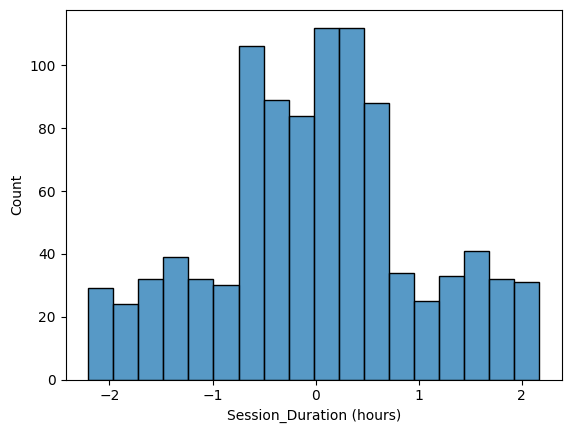

In [68]:
import seaborn as sns
column1 = gym['Session_Duration (hours)']
sns.histplot(data=gym, x=column1)

<Axes: xlabel='Calories_Burned', ylabel='Count'>

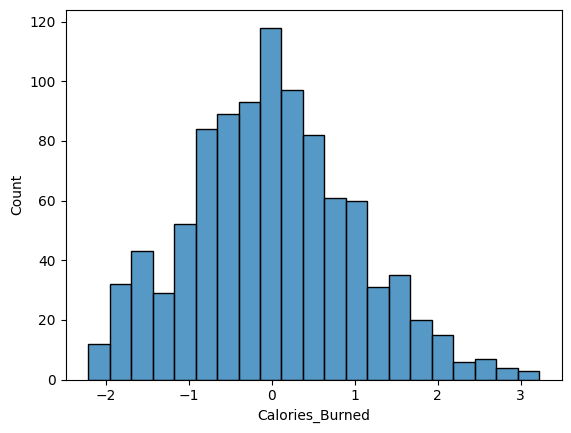

In [69]:
import seaborn as sns
column2 = gym['Calories_Burned']
sns.histplot(data=gym, x=column2)

<Axes: xlabel='Avg_BPM', ylabel='Count'>

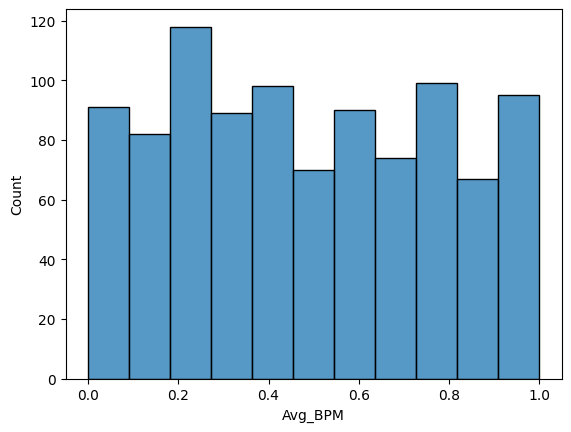

In [70]:
import seaborn as sns
column3 = gym['Avg_BPM']
sns.histplot(data=gym, x=column3)

<Axes: xlabel='Resting_BPM', ylabel='Count'>

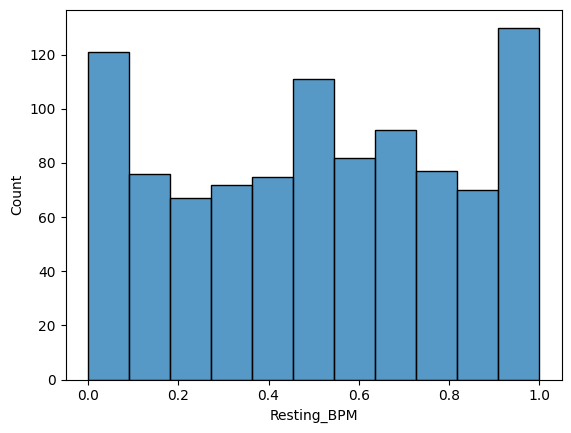

In [71]:
import seaborn as sns
column4 = gym['Resting_BPM']
sns.histplot(data=gym, x=column4)

<Axes: xlabel='Weight (kg)', ylabel='Count'>

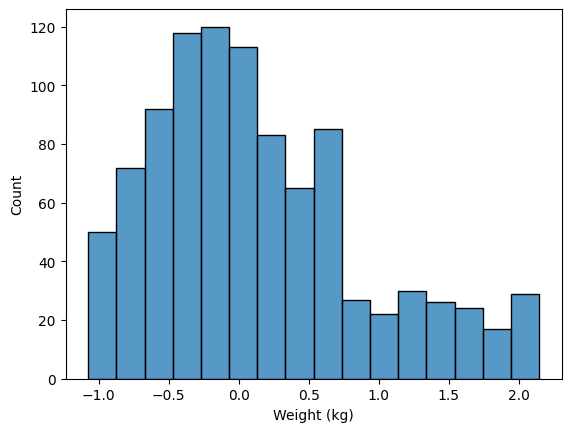

In [72]:
import seaborn as sns
column5 = gym['Weight (kg)']
sns.histplot(data=gym, x=column5)

<Axes: xlabel='Height (m)', ylabel='Count'>

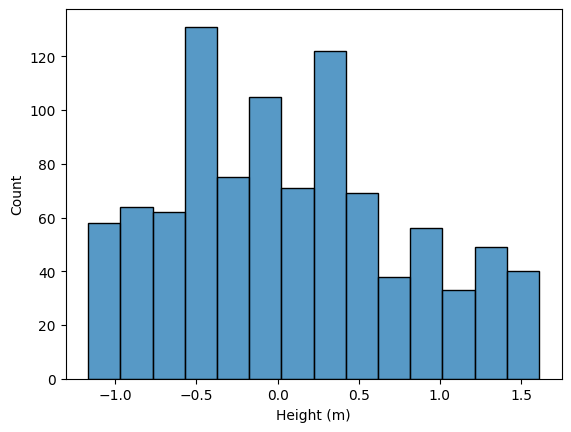

In [73]:
import seaborn as sns
column6 = gym['Height (m)']
sns.histplot(data=gym, x=column6)